In [1]:
import pandas as pd
import numpy as np
import joblib
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Library modeling berhasil di-import")

Library modeling berhasil di-import


In [2]:
df = pd.read_csv("../data/processed/fraud_clean.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_Log,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0


In [3]:
X = df.drop("Class", axis=1)
y = df["Class"]

print(X.shape)
print(y.shape)

(284807, 32)
(284807,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("Distribusi y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("Distribusi y_test:")
print(y_test.value_counts(normalize=True) * 100)

X_train: (227845, 32)
X_test: (56962, 32)
Distribusi y_train:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64
Distribusi y_test:
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling selesai")

Scaling selesai


In [6]:
joblib.dump(scaler, "../models/scaler.pkl")
print("Scaler berhasil disimpan")

Scaler berhasil disimpan


In [7]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Sebelum SMOTE:")
print(y_train.value_counts())

print("Sesudah SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Sebelum SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64
Sesudah SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [8]:
def evaluate_model(model_name, y_true, y_pred, y_proba):
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba)
    }
    
    print(f"===== {model_name} =====")
    print(classification_report(y_true, y_pred))
    print("ROC-AUC:", result["ROC-AUC"])
    print("PR-AUC:", result["PR-AUC"])
    
    return result

In [9]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_balanced, y_train_balanced)

y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

result_log = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_log,
    y_proba_log
)

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.54     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC: 0.9735408794919206
PR-AUC: 0.7315787895461129


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_balanced, y_train_balanced)

y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

result_rf = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_proba_rf
)

===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.43      0.85      0.57        98

    accuracy                           1.00     56962
   macro avg       0.72      0.92      0.79     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.982626287712609
PR-AUC: 0.7960816526917829


In [11]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_balanced, y_train_balanced)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

result_xgb = evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_proba_xgb
)

===== XGBoost =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.41      0.87      0.55        98

    accuracy                           1.00     56962
   macro avg       0.70      0.93      0.78     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9836209631573508
PR-AUC: 0.8470622835742608


In [12]:
model_comparison = pd.DataFrame([
    result_log,
    result_rf,
    result_xgb
])

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.972596,0.054778,0.918367,0.103389,0.973541,0.731579
1,Random Forest,0.997823,0.432292,0.846939,0.572414,0.982626,0.796082
2,XGBoost,0.997595,0.406699,0.867347,0.553746,0.983621,0.847062


In [13]:
os.makedirs("../reports", exist_ok=True)

model_comparison.to_csv("../reports/model_comparison.csv", index=False)

print("model_comparison.csv berhasil disimpan")

model_comparison.csv berhasil disimpan


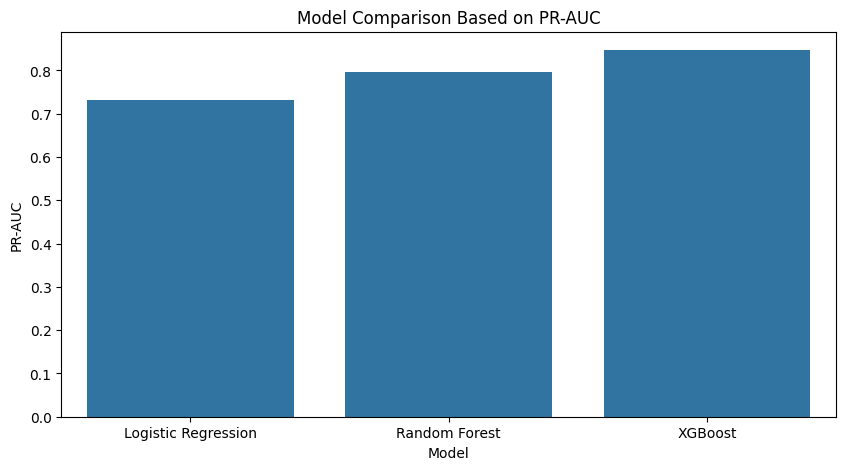

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(data=model_comparison, x="Model", y="PR-AUC")
plt.title("Model Comparison Based on PR-AUC")
plt.ylabel("PR-AUC")
plt.xlabel("Model")
plt.show()

In [15]:
best_model = xgb_model
best_model_name = "XGBoost"
y_proba_best = y_proba_xgb

In [16]:
threshold_list = [0.1, 0.2, 0.3, 0.4, 0.5]

threshold_results = []

for threshold in threshold_list:
    y_pred_threshold = (y_proba_best >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.1,0.077729,0.908163,0.143202
1,0.2,0.146382,0.908163,0.252125
2,0.3,0.228947,0.887755,0.364017
3,0.4,0.324627,0.887755,0.475410
4,0.5,0.406699,0.867347,0.553746


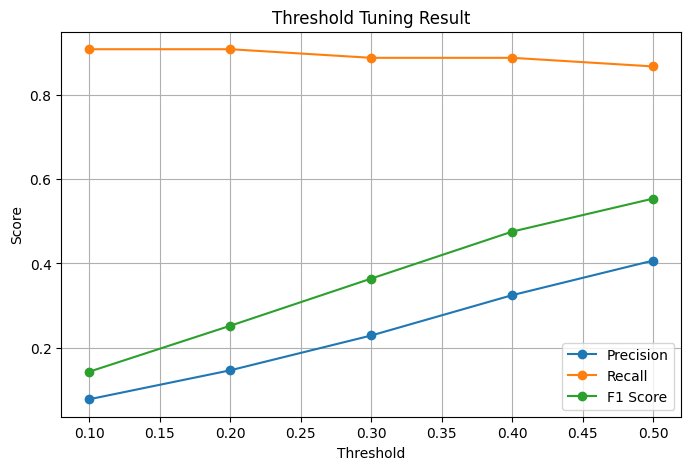

In [17]:
plt.figure(figsize=(8,5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1 Score"], marker="o", label="F1 Score")
plt.title("Threshold Tuning Result")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
final_threshold = 0.3

y_pred_final = (y_proba_best >= final_threshold).astype(int)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.23      0.89      0.36        98

    accuracy                           0.99     56962
   macro avg       0.61      0.94      0.68     56962
weighted avg       1.00      0.99      1.00     56962



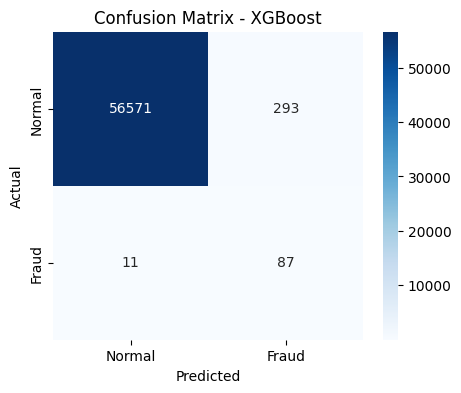

In [20]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

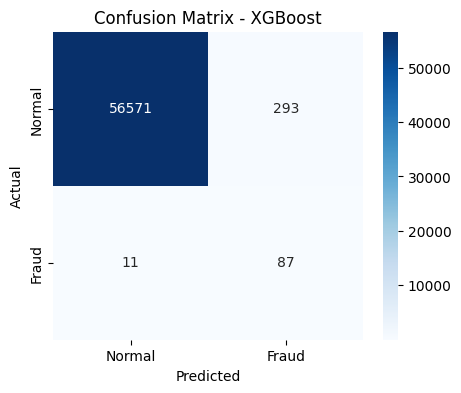

In [21]:
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../reports/confusion_matrix.png", bbox_inches="tight")
plt.show()

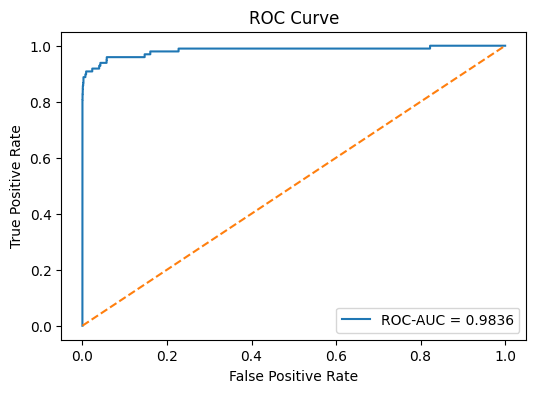

In [22]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_best)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba_best):.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

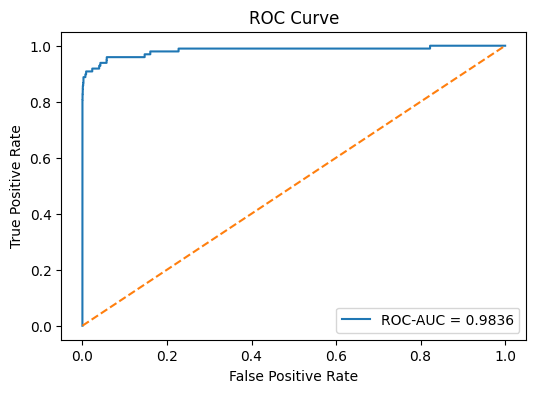

In [23]:
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba_best):.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("../reports/roc_curve.png", bbox_inches="tight")
plt.show()

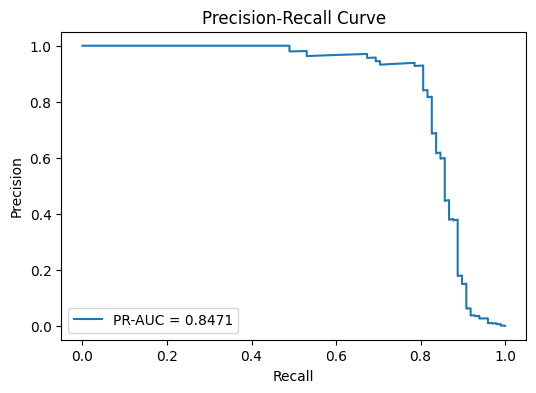

In [24]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba_best)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_test, y_proba_best):.4f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

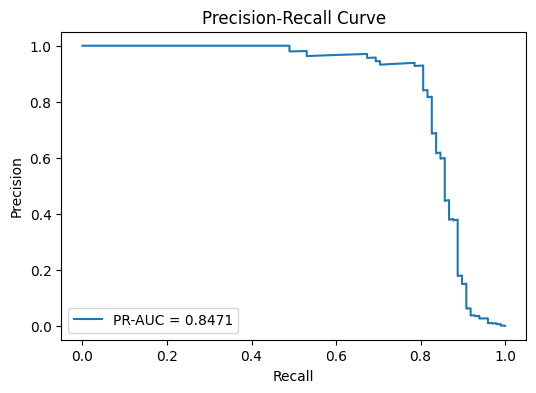

In [25]:
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_test, y_proba_best):.4f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.savefig("../reports/pr_curve.png", bbox_inches="tight")
plt.show()

In [27]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
14,V14,0.435820
10,V10,0.135351
4,V4,0.048596
8,V8,0.033382
12,V12,0.030114
13,V13,0.018642
30,Amount_Log,0.018484
18,V18,0.017952
17,V17,0.016042
0,Time,0.015959


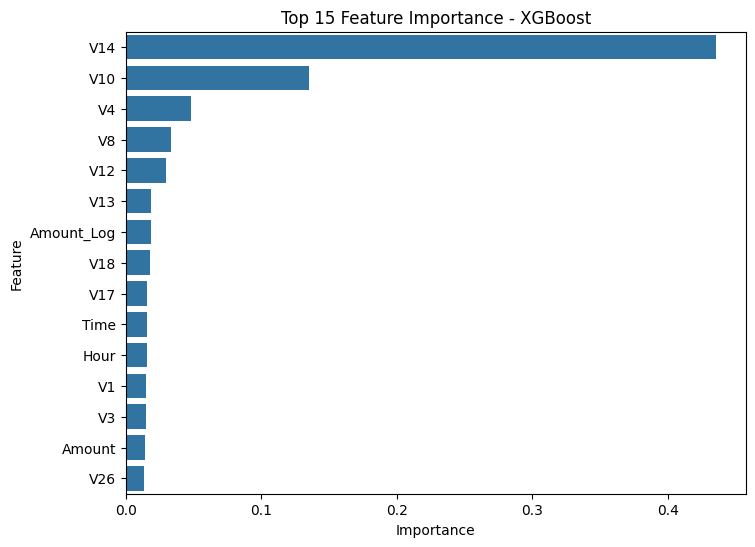

In [28]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

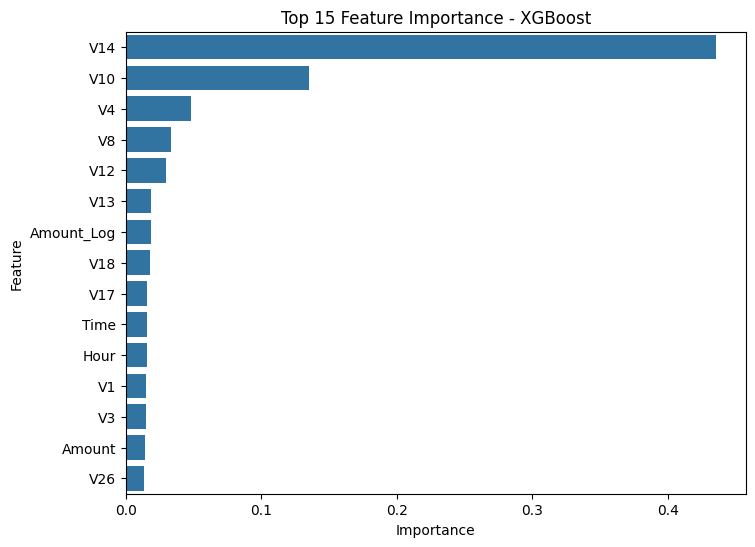

In [29]:
feature_importance.to_csv("../reports/feature_importance.csv", index=False)

plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("../reports/feature_importance.png", bbox_inches="tight")
plt.show()

In [30]:
joblib.dump(best_model, "../models/fraud_model.pkl")
joblib.dump(X.columns.tolist(), "../models/feature_names.pkl")

print("Model, scaler, dan feature names berhasil disimpan")

Model, scaler, dan feature names berhasil disimpan


In [31]:
prediction_result = X_test.copy()

prediction_result["Actual_Class"] = y_test.values
prediction_result["Fraud_Probability"] = y_proba_best
prediction_result["Predicted_Class"] = y_pred_final

In [32]:
def risk_category(prob):
    if prob >= 0.7:
        return "High Risk"
    elif prob >= 0.3:
        return "Medium Risk"
    else:
        return "Low Risk"

prediction_result["Risk_Category"] = prediction_result["Fraud_Probability"].apply(risk_category)

In [33]:
prediction_result.to_csv("../data/processed/fraud_prediction_result.csv", index=False)

print("fraud_prediction_result.csv berhasil disimpan")

fraud_prediction_result.csv berhasil disimpan


In [34]:
dashboard_result = prediction_result[
    [
        "Amount",
        "Amount_Log",
        "Hour",
        "Actual_Class",
        "Predicted_Class",
        "Fraud_Probability",
        "Risk_Category"
    ]
]

dashboard_result.to_csv("../data/processed/fraud_dashboard_data.csv", index=False)

print("fraud_dashboard_data.csv berhasil disimpan")
dashboard_result.head()

fraud_dashboard_data.csv berhasil disimpan


,Amount,Amount_Log,Hour,Actual_Class,Predicted_Class,Fraud_Probability,Risk_Category
263020,23.00,3.178054,20,0,0,0.000292,Low Risk
11378,11.85,2.553344,5,0,0,0.000040,Low Risk
147283,76.07,4.344714,0,0,0,0.000408,Low Risk
219439,0.99,0.688135,15,0,0,0.000051,Low Risk
36939,1.50,0.916291,10,0,0,0.008472,Low Risk


In [35]:
import numpy as np

prediction_result["Amount_Log"] = np.log1p(prediction_result["Amount"])
prediction_result["Hour"] = ((prediction_result["Time"] / 3600) % 24).astype(int)

dashboard_result = prediction_result[
    [
        "Amount",
        "Amount_Log",
        "Hour",
        "Actual_Class",
        "Predicted_Class",
        "Fraud_Probability",
        "Risk_Category"
    ]
]

dashboard_result.to_csv("../data/processed/fraud_dashboard_data.csv", index=False)

print("fraud_dashboard_data.csv berhasil disimpan")
dashboard_result.head()

fraud_dashboard_data.csv berhasil disimpan


,Amount,Amount_Log,Hour,Actual_Class,Predicted_Class,Fraud_Probability,Risk_Category
263020,23.00,3.178054,20,0,0,0.000292,Low Risk
11378,11.85,2.553344,5,0,0,0.000040,Low Risk
147283,76.07,4.344714,0,0,0,0.000408,Low Risk
219439,0.99,0.688135,15,0,0,0.000051,Low Risk
36939,1.50,0.916291,10,0,0,0.008472,Low Risk
